# 06 — Lucas-Kanade Optical Flow Training: Conv2D + ConvLSTM
### SIBI Lip Reading — Dataset Gabungan (Angka + Alphabet + Kata)

Notebook ini melatih model Conv2D + ConvLSTM menggunakan input  
**Lucas-Kanade sparse optical flow** (u, v, magnitude) hasil dari Notebook 04.

Arsitektur identik dengan Baseline (Notebook 05) — hanya sumber input yang berbeda,  
sehingga perbandingan RGB vs Optical Flow bersifat *apple-to-apple*.

In [21]:
# ── Cell 1: Import ──────────────────────────────────────────────────────────
import json, time, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score, precision_score, recall_score
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {device}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')

PyTorch : 2.11.0+cu128
Device  : cuda
GPU     : NVIDIA GeForce RTX 5050 Laptop GPU
VRAM    : 8.09 GB


In [22]:
# ── Cell 2: Config ──────────────────────────────────────────────────────────
BASE_DIR     = Path('/home/wipra-ranum/Documents/Skripsi/LipReading')
PROJECT_ROOT = BASE_DIR / 'Lip_Reading_Gabungan'
FLOWS_DIR    = PROJECT_ROOT / 'preprocessed' / 'dependent' / 'flows_lucaskanade'
MODELS_DIR   = PROJECT_ROOT / 'models'
RESULTS_DIR  = PROJECT_ROOT / 'results' / 'lk_training'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

with open(PROJECT_ROOT / 'config.json') as f:
    cfg = json.load(f)

CLASSES      = cfg['data']['classes']
NUM_CLASSES  = len(CLASSES)
IDX_TO_CLASS = {i: c for i, c in enumerate(CLASSES)}
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}

# Hyperparameter identik dengan baseline untuk perbandingan fair
BATCH_SIZE   = 8
NUM_EPOCHS   = 100
LR           = 0.001
WEIGHT_DECAY = 1e-5
SEED         = 42
SEQ_LEN      = 29    # T-1 = 30-1 frame flow

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

print(f'Data    : {FLOWS_DIR}')
print(f'Classes : {NUM_CLASSES} kelas — {CLASSES}')
print(f'Epochs  : {NUM_EPOCHS} | Batch: {BATCH_SIZE} | LR: {LR}')
print(f'Seq len : {SEQ_LEN} frames (T-1, dari 30 frame raw)')
print(f'Input ch: 3 (u, v, magnitude) — bukan RGB')

Data    : /home/wipra-ranum/Documents/Skripsi/LipReading/Lip_Reading_Gabungan/preprocessed/dependent/flows_lucaskanade
Classes : 18 kelas — ['1', '2', '3', '8', '9', '10', 'a', 'b', 'c', 'd', 'e', 'f', 'buku', 'dia', 'saya', 'keliling', 'kelompok', 'sekarang']
Epochs  : 100 | Batch: 8 | LR: 0.001
Seq len : 29 frames (T-1, dari 30 frame raw)
Input ch: 3 (u, v, magnitude) — bukan RGB


---
## Dataset & DataLoader

In [23]:
# ── Cell 3: Dataset ─────────────────────────────────────────────────────────
class LKFlowDataset(Dataset):
    """
    Load .npy optical flow sequences [T-1, H, W, 3] → tensor [3, T-1, H, W].

    Data sudah ternormalisasi (clip + z-score) dari Notebook 04.
    Augmentasi: horizontal flip + negate channel u (semantic-correct).
      - Flip tanpa negate u akan membalik arah gerak, yang salah secara fisik.
    """

    def __init__(self, root, classes, split, seq_len=29, augment=False):
        self.samples  = []
        self.labels   = []
        self.seq_len  = seq_len
        self.augment  = augment

        for idx, cls in enumerate(classes):
            d = Path(root) / split / cls
            if not d.exists():
                print(f'  Warning: {d} tidak ditemukan')
                continue
            for f in sorted(d.glob('*.npy')):
                self.samples.append(f)
                self.labels.append(idx)
        print(f'  {split:5s}: {len(self.samples)} samples')

    def _fix_len(self, seq):
        """Pad atau subsample supaya panjang = seq_len."""
        T = len(seq)
        if T == self.seq_len:
            return seq
        if T < self.seq_len:
            pad = np.zeros((self.seq_len - T, *seq.shape[1:]), dtype=np.float32)
            return np.concatenate([seq, pad])
        # linspace subsample → semua bagian temporal terwakili merata
        return seq[np.linspace(0, T - 1, self.seq_len, dtype=int)]

    def _augment(self, seq):
        """Horizontal flip + negate u (channel 0)."""
        if np.random.random() > 0.5:
            seq = seq[:, :, ::-1, :].copy()   # flip spatial W
            seq[..., 0] *= -1                  # negate u channel
        return seq

    def __len__(self): return len(self.samples)

    def __getitem__(self, i):
        seq = np.load(self.samples[i]).astype(np.float32)  # [T-1, H, W, 3]
        if self.augment:
            seq = self._augment(seq)
        seq = self._fix_len(seq)                            # [seq_len, H, W, 3]
        seq = torch.from_numpy(seq.transpose(3, 0, 1, 2))  # [3, seq_len, H, W]
        return seq, torch.tensor(self.labels[i], dtype=torch.long)

In [24]:
# ── Cell 4: DataLoader ──────────────────────────────────────────────────────
print('Loading datasets...')
train_ds = LKFlowDataset(FLOWS_DIR, CLASSES, 'train', SEQ_LEN, augment=True)
val_ds   = LKFlowDataset(FLOWS_DIR, CLASSES, 'val',   SEQ_LEN, augment=False)
test_ds  = LKFlowDataset(FLOWS_DIR, CLASSES, 'test',  SEQ_LEN, augment=False)

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f'\nTrain : {len(train_ds)} samples ({len(train_loader)} batches)')
print(f'Val   : {len(val_ds)} samples ({len(val_loader)} batches)')
print(f'Test  : {len(test_ds)} samples ({len(test_loader)} batches)')

x, y = next(iter(train_loader))
print(f'\nBatch shape  : {x.shape}   (expected [8, 3, {SEQ_LEN}, 96, 96])')
print(f'Value range  : [{x.min():.3f}, {x.max():.3f}]  (sudah ternormalisasi)')
print(f'Label sample : {[IDX_TO_CLASS[l.item()] for l in y]}')

Loading datasets...
  train: 2519 samples
  val  : 720 samples
  test : 360 samples

Train : 2519 samples (315 batches)
Val   : 720 samples (90 batches)
Test  : 360 samples (45 batches)

Batch shape  : torch.Size([8, 3, 29, 96, 96])   (expected [8, 3, 29, 96, 96])
Value range  : [-2.441, 2.932]  (sudah ternormalisasi)
Label sample : ['8', 'b', 'sekarang', '3', '9', 'keliling', 'kelompok', '2']


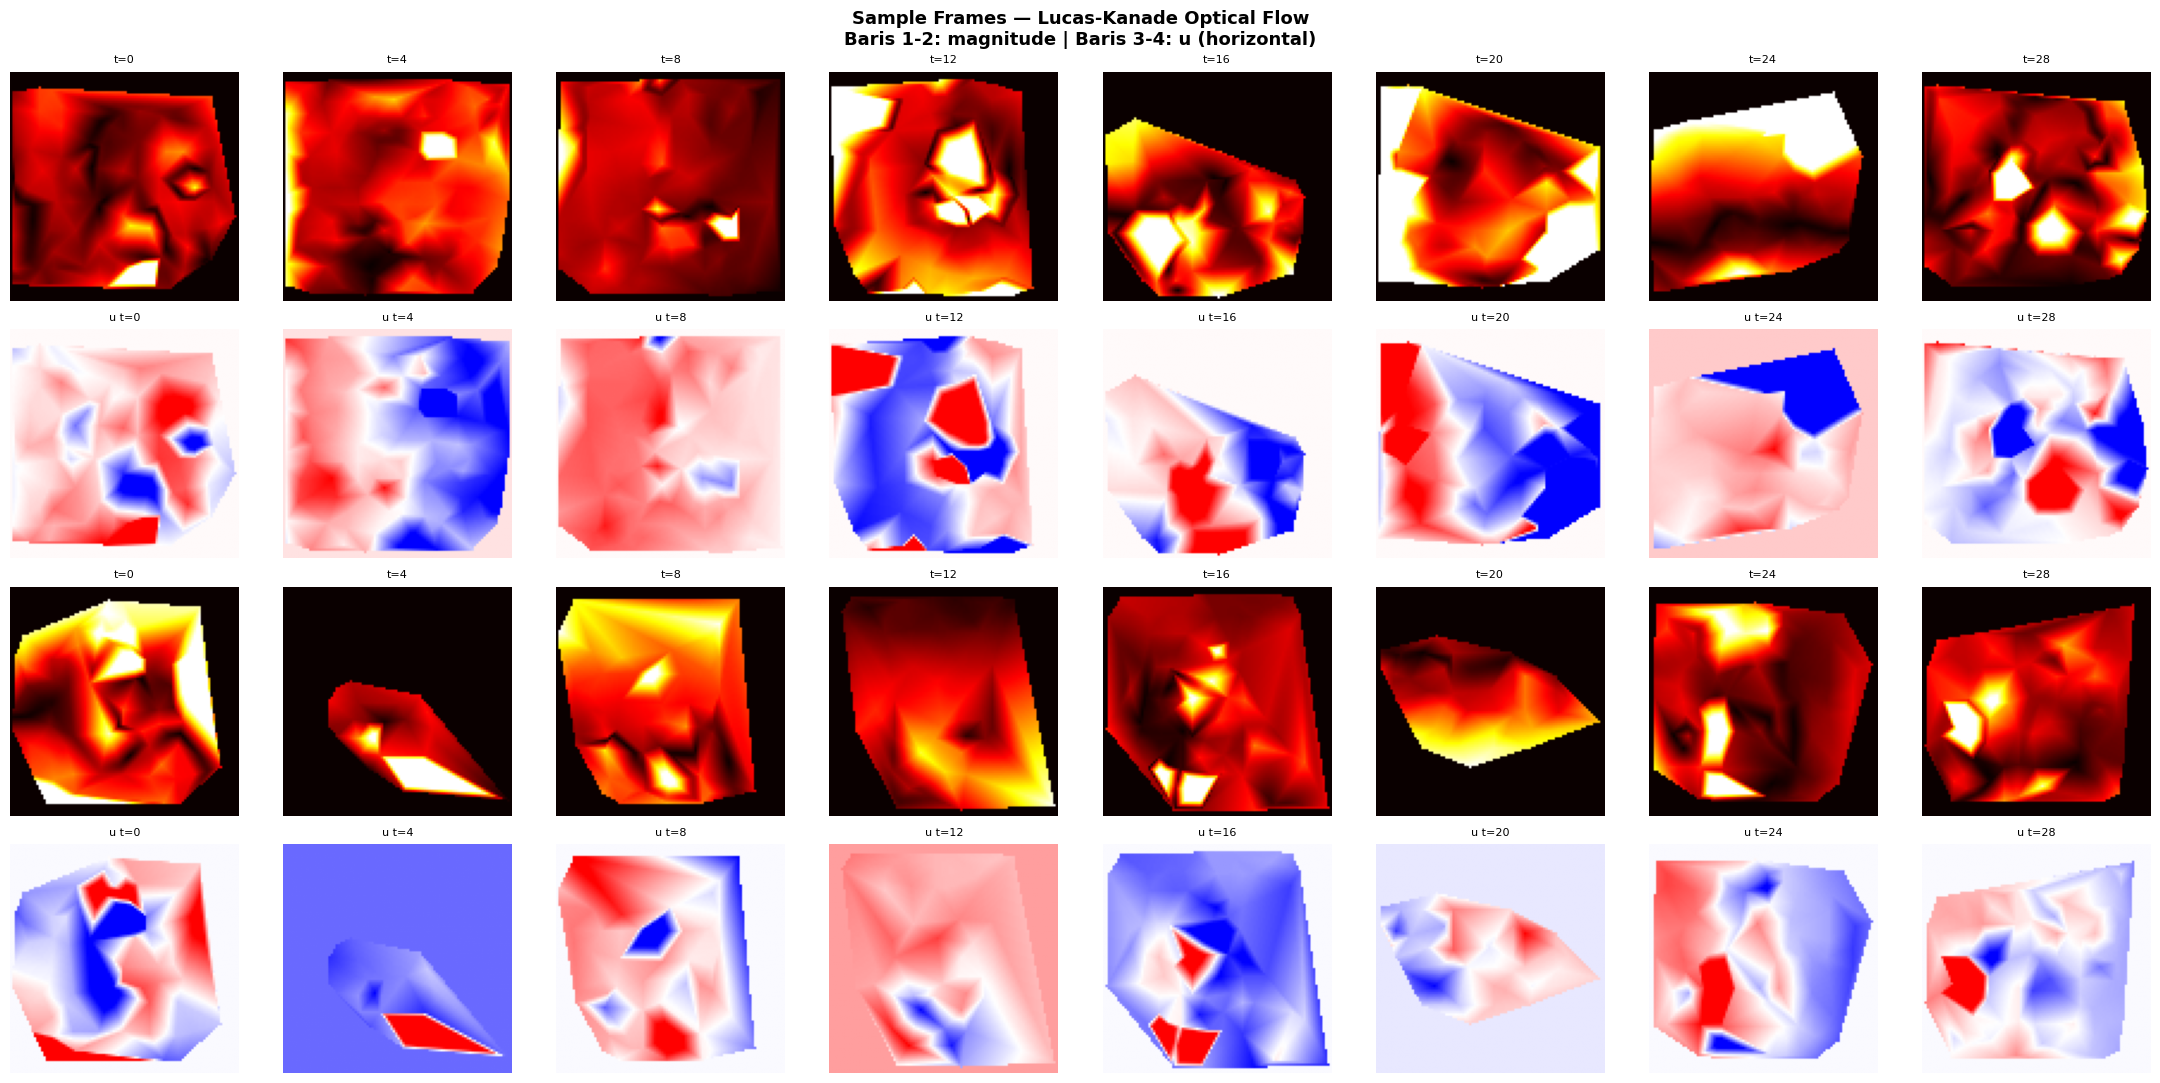

Saved: sample_flow_frames.png


In [25]:
# ── Cell 5: Visualisasi sampel flow ─────────────────────────────────────────
fig, axes = plt.subplots(4, 8, figsize=(22, 11))
fig.suptitle('Sample Frames — Lucas-Kanade Optical Flow\n'
             'Baris 1-2: magnitude | Baris 3-4: u (horizontal)',
             fontsize=13, fontweight='bold')

for row in range(2):
    seq, lbl = train_ds[random.randint(0, len(train_ds)-1)]
    cls_name = IDX_TO_CLASS[lbl.item()]
    for col, t in enumerate(np.linspace(0, SEQ_LEN-1, 8, dtype=int)):
        # row*2: magnitude (ch=2)
        axes[row*2][col].imshow(seq[2, t].numpy(), cmap='hot')
        axes[row*2][col].set_title(f't={t}', fontsize=8)
        axes[row*2][col].axis('off')
        # row*2+1: u channel (ch=0)
        axes[row*2+1][col].imshow(seq[0, t].numpy(), cmap='bwr')
        axes[row*2+1][col].set_title(f'u t={t}', fontsize=8)
        axes[row*2+1][col].axis('off')
    axes[row*2][0].set_ylabel(f'magnitude\n"{cls_name}"', fontsize=9, fontweight='bold')
    axes[row*2+1][0].set_ylabel(f'u channel\n"{cls_name}"', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'sample_flow_frames.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sample_flow_frames.png')

---
## Arsitektur Model: Conv2D + ConvLSTM

In [26]:
# ── Cell 6: ConvLSTM Cell ───────────────────────────────────────────────────
class ConvLSTMCell(nn.Module):
    """
    ConvLSTM: menggantikan matrix multiplication LSTM dengan Conv2D.
    Informasi spasial tetap terjaga di dalam hidden state.
    Ref: Shi et al. (2015), NeurIPS.
    """
    def __init__(self, in_ch, h_ch, k=3):
        super().__init__()
        self.h_ch = h_ch
        self.conv = nn.Conv2d(in_ch + h_ch, 4 * h_ch, k, padding=k // 2)

    def forward(self, x, state):
        h, c = state
        i, f, o, g = torch.split(self.conv(torch.cat([x, h], dim=1)), self.h_ch, dim=1)
        i = torch.sigmoid(i)
        f = torch.sigmoid(f)
        o = torch.sigmoid(o)
        g = torch.tanh(g)
        c_next = f * c + i * g
        h_next = o * torch.tanh(c_next)
        return h_next, c_next

    def init_hidden(self, B, H, W, dev):
        return (torch.zeros(B, self.h_ch, H, W, device=dev),
                torch.zeros(B, self.h_ch, H, W, device=dev))

In [27]:
# ── Cell 7: Model utama ──────────────────────────────────────────────────────
class LKFlowModel(nn.Module):
    """
    Conv2D per-frame (spatial) → ConvLSTM (temporal) → Classifier.
    Identik dengan BaselineModel, perbedaan hanya di sumber input:
      Baseline  : [B, 3, 30, 96, 96]  — RGB
      LK Flow   : [B, 3, 29, 96, 96]  — u, v, magnitude
    """
    def __init__(self, num_classes=10, dropout=0.5):
        super().__init__()

        def cblock(ic, oc):
            return nn.Sequential(
                nn.Conv2d(ic, oc, 3, padding=1),
                nn.BatchNorm2d(oc),
                nn.ReLU(),
                nn.MaxPool2d(2)
            )

        # Spatial CNN: 96 → 48 → 24 → 12
        self.cnn   = nn.Sequential(cblock(3, 32), cblock(32, 64), cblock(64, 128))
        self.lstm1 = ConvLSTMCell(128, 128)
        self.lstm2 = ConvLSTMCell(128, 64)
        self.head  = nn.Sequential(
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):                               # x: [B, 3, T, H, W]
        B, C, T, H, W = x.shape
        x = x.permute(0, 2, 1, 3, 4).reshape(B*T, C, H, W)
        x = self.cnn(x)                                 # [B*T, 128, 12, 12]
        _, c, h, w = x.shape
        x = x.view(B, T, c, h, w)

        h1, c1 = self.lstm1.init_hidden(B, h, w, x.device)
        h2, c2 = self.lstm2.init_hidden(B, h, w, x.device)
        for t in range(T):
            h1, c1 = self.lstm1(x[:, t], (h1, c1))
            h2, c2 = self.lstm2(h1, (h2, c2))

        out = h2.mean(dim=[-2, -1])                     # Global Avg Pool → [B, 64]
        return self.head(out)

In [28]:
# ── Cell 8: Init model + ukur efisiensi ────────────────────────────────────
model = LKFlowModel(num_classes=NUM_CLASSES, dropout=0.5).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
model_size_mb    = total_params * 4 / 1e6

dummy = torch.randn(1, 3, SEQ_LEN, 96, 96).to(device)

try:
    from thop import profile, clever_format
    macs, _ = profile(model, inputs=(dummy,), verbose=False)
    gflops  = macs * 2 / 1e9
    gflops_str = f'{gflops:.3f} GFLOPs'
except ImportError:
    gflops = total_params * SEQ_LEN * 2 / 1e9
    gflops_str = f'~{gflops:.3f} GFLOPs (estimasi)'

model.eval()
with torch.no_grad():
    for _ in range(5): _ = model(dummy)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(50): _ = model(dummy)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    infer_ms = (time.time() - t0) / 50 * 1000
model.train()

with torch.no_grad():
    out_test = model(torch.randn(2, 3, SEQ_LEN, 96, 96).to(device))

print('=' * 55)
print('  MODEL SUMMARY')
print('=' * 55)
print(f'  Arsitektur       : Conv2D + ConvLSTM (LK Flow)')
print(f'  Input            : [B, 3, {SEQ_LEN}, 96, 96]  (u, v, mag)')
print(f'  Total params     : {total_params:,}')
print(f'  Trainable params : {trainable_params:,}')
print(f'  Model size       : {model_size_mb:.2f} MB (float32)')
print(f'  GFLOPs           : {gflops_str}')
print(f'  Inference time   : {infer_ms:.2f} ms/sample')
print(f'  Output shape     : {out_test.shape}  (expected [2, {NUM_CLASSES}])')
print('=' * 55)

  MODEL SUMMARY
  Arsitektur       : Conv2D + ConvLSTM (LK Flow)
  Input            : [B, 3, 29, 96, 96]  (u, v, mag)
  Total params     : 1,737,746
  Trainable params : 1,737,746
  Model size       : 6.95 MB (float32)
  GFLOPs           : ~0.101 GFLOPs (estimasi)
  Inference time   : 7.91 ms/sample
  Output shape     : torch.Size([2, 18])  (expected [2, 18])


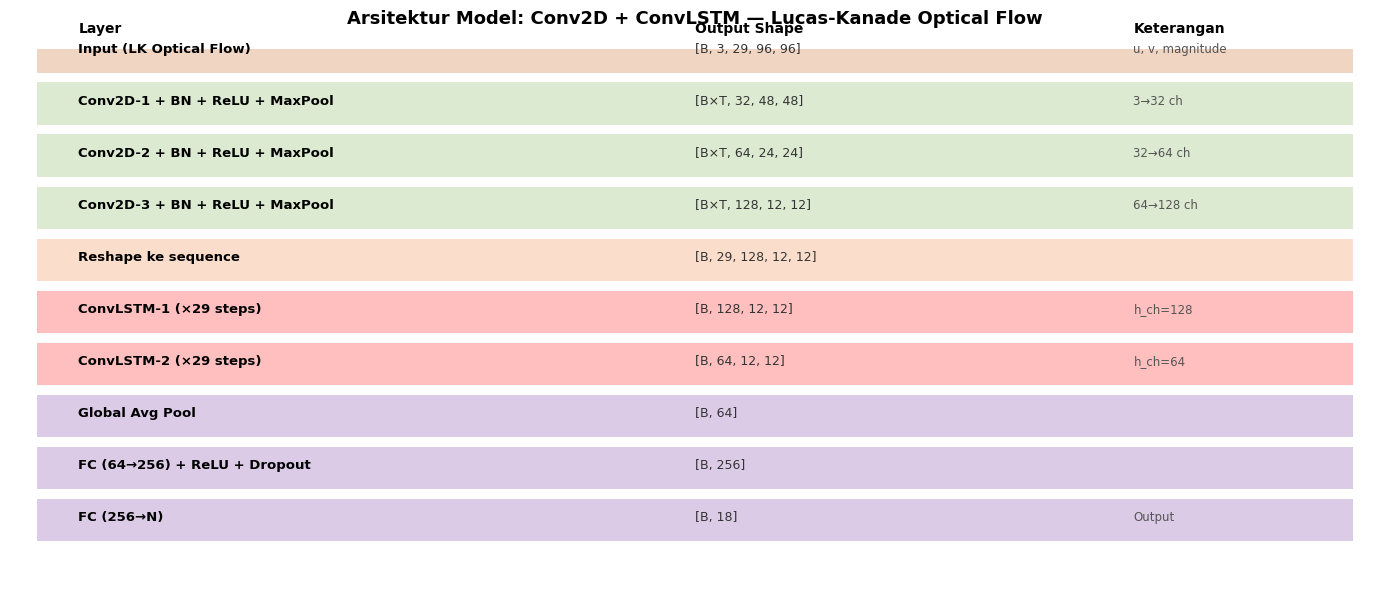

Saved: model_architecture.png


In [29]:
# ── Cell 9: Visualisasi arsitektur model ───────────────────────────────────
layers_info = [
    ('Input (LK Optical Flow)',        f'[B, 3, {SEQ_LEN}, 96, 96]',    'u, v, magnitude'),
    ('Conv2D-1 + BN + ReLU + MaxPool', '[B×T, 32, 48, 48]',             '3→32 ch'),
    ('Conv2D-2 + BN + ReLU + MaxPool', '[B×T, 64, 24, 24]',             '32→64 ch'),
    ('Conv2D-3 + BN + ReLU + MaxPool', '[B×T, 128, 12, 12]',            '64→128 ch'),
    ('Reshape ke sequence',            f'[B, {SEQ_LEN}, 128, 12, 12]',  ''),
    ('ConvLSTM-1 (×29 steps)',         '[B, 128, 12, 12]',               'h_ch=128'),
    ('ConvLSTM-2 (×29 steps)',         '[B, 64, 12, 12]',                'h_ch=64'),
    ('Global Avg Pool',                '[B, 64]',                        ''),
    ('FC (64→256) + ReLU + Dropout',   '[B, 256]',                       ''),
    ('FC (256→N)',                     f'[B, {NUM_CLASSES}]',            'Output'),
]

fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')
colors = ['#C55A11'] + ['#70AD47'] * 3 + ['#ED7D31'] + ['#FF0000'] * 2 + ['#7030A0'] * 3
for i, (name, shape, note) in enumerate(layers_info):
    y = 1 - i * 0.098
    ax.add_patch(plt.Rectangle((0.02, y - 0.045), 0.96, 0.08,
                                facecolor=colors[i], alpha=0.25, transform=ax.transAxes))
    ax.text(0.05, y, name,  transform=ax.transAxes, va='center', fontsize=9.5, fontweight='bold')
    ax.text(0.50, y, shape, transform=ax.transAxes, va='center', fontsize=9,   color='#333')
    ax.text(0.82, y, note,  transform=ax.transAxes, va='center', fontsize=8.5, color='#555')

ax.text(0.05, 1.03, 'Layer',        transform=ax.transAxes, fontsize=10, fontweight='bold')
ax.text(0.50, 1.03, 'Output Shape', transform=ax.transAxes, fontsize=10, fontweight='bold')
ax.text(0.82, 1.03, 'Keterangan',  transform=ax.transAxes, fontsize=10, fontweight='bold')
ax.set_title('Arsitektur Model: Conv2D + ConvLSTM — Lucas-Kanade Optical Flow',
             fontsize=13, fontweight='bold', pad=18)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model_architecture.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_architecture.png')

---
## Training

In [30]:
# ── Cell 10: Loss, optimizer, scheduler ─────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-6)

print('Loss      : CrossEntropyLoss')
print('Optimizer : Adam')
print('Scheduler : ReduceLROnPlateau (mode=max, factor=0.5, patience=5)')

Loss      : CrossEntropyLoss
Optimizer : Adam
Scheduler : ReduceLROnPlateau (mode=max, factor=0.5, patience=5)


In [31]:
# ── Cell 11: Fungsi train & eval ────────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    loss_sum, correct, total = 0., 0, 0
    for x, y in tqdm(loader, desc='Train', leave=False):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out  = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * x.size(0)
        correct  += (out.argmax(1) == y).sum().item()
        total    += y.size(0)
    return loss_sum / total, 100. * correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum, correct, total = 0., 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in tqdm(loader, desc='Eval', leave=False):
            x, y = x.to(device), y.to(device)
            out  = model(x)
            loss = criterion(out, y)
            loss_sum += loss.item() * x.size(0)
            pred = out.argmax(1)
            correct  += (pred == y).sum().item()
            total    += y.size(0)
            all_preds.extend(pred.cpu().tolist())
            all_labels.extend(y.cpu().tolist())

    avg_loss = loss_sum / total
    accuracy = 100. * correct / total
    per_class = {}
    for ci in range(NUM_CLASSES):
        mask = [l == ci for l in all_labels]
        if any(mask):
            c = sum(p == ci for p, m in zip(all_preds, mask) if m)
            per_class[ci] = 100. * c / sum(mask)
        else:
            per_class[ci] = 0.
    return avg_loss, accuracy, per_class, all_preds, all_labels

In [32]:
# ── Cell 12: Training loop ──────────────────────────────────────────────────
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': [], 'epoch_time': []}

best_val_acc    = 0.
best_epoch      = 0
best_model_path = MODELS_DIR / 'lk_gabungan_best.pth'

t_start = time.time()
print(f'Training {NUM_EPOCHS} epochs | {len(train_loader)} batches/epoch | {NUM_CLASSES} kelas\n')
print(f'{"Epoch":>6}  {"TrainLoss":>10} {"TrainAcc":>9} {"ValLoss":>9} {"ValAcc":>8}  {"LR":>8}  {"Time":>6}  {"Flag"}')
print('-' * 90)

for epoch in range(1, NUM_EPOCHS + 1):
    t_ep = time.time()

    tr_loss, tr_acc                = train_one_epoch(model, train_loader, criterion, optimizer, device)
    va_loss, va_acc, per_cls, _, _ = evaluate(model, val_loader, criterion, device)

    scheduler.step(va_acc)
    cur_lr     = optimizer.param_groups[0]['lr']
    epoch_time = time.time() - t_ep

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss)
    history['val_acc'].append(va_acc)
    history['lr'].append(cur_lr)
    history['epoch_time'].append(epoch_time)

    flag = ''
    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_epoch   = epoch
        torch.save({
            'epoch'               : epoch,
            'model_state_dict'    : model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc'             : va_acc,
            'val_loss'            : va_loss,
            'num_classes'         : NUM_CLASSES,
            'classes'             : CLASSES,
            'method'              : 'lucas-kanade'
        }, best_model_path)
        flag = '<-- best'

    print(f'{epoch:6d}  {tr_loss:10.4f} {tr_acc:9.2f}% {va_loss:9.4f} {va_acc:8.2f}%  {cur_lr:8.2e}  {epoch_time:5.0f}s  {flag}')

    cls_str = '  '.join([f'{IDX_TO_CLASS[k]}:{v:.0f}%' for k, v in per_cls.items()])
    print(f'         per-class: {cls_str}')

    if torch.cuda.is_available() and epoch % 5 == 0:
        torch.cuda.empty_cache()

total_time = time.time() - t_start
print('\n' + '=' * 90)
print(f'Training selesai dalam {total_time/60:.1f} menit')
print(f'Best val acc: {best_val_acc:.2f}% di epoch {best_epoch}')
print(f'Model disimpan: {best_model_path}')

Training 100 epochs | 315 batches/epoch | 18 kelas

 Epoch   TrainLoss  TrainAcc   ValLoss   ValAcc        LR    Time  Flag
------------------------------------------------------------------------------------------


Train:   0%|          | 0/315 [00:00<?, ?it/s]

Eval:   0%|          | 0/90 [00:00<?, ?it/s]

     1      2.8587      7.58%    2.8250     9.44%  1.00e-03     57s  <-- best
         per-class: 1:0%  2:2%  3:5%  8:0%  9:0%  10:70%  a:10%  b:0%  c:0%  d:12%  e:0%  f:0%  buku:0%  dia:8%  saya:0%  keliling:62%  kelompok:0%  sekarang:0%


Train:   0%|          | 0/315 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/90 [00:00<?, ?it/s]

    99      0.0079     99.96%    2.8572    50.00%  1.00e-06     57s  
         per-class: 1:68%  2:70%  3:32%  8:72%  9:55%  10:62%  a:58%  b:62%  c:30%  d:38%  e:45%  f:50%  buku:62%  dia:42%  saya:20%  keliling:62%  kelompok:45%  sekarang:25%


Train:   0%|          | 0/315 [00:00<?, ?it/s]

Eval:   0%|          | 0/90 [00:00<?, ?it/s]

   100      0.0101     99.96%    2.8539    50.00%  1.00e-06     57s  
         per-class: 1:68%  2:70%  3:32%  8:72%  9:55%  10:62%  a:58%  b:62%  c:30%  d:35%  e:48%  f:50%  buku:60%  dia:45%  saya:18%  keliling:60%  kelompok:48%  sekarang:28%

Training selesai dalam 95.4 menit
Best val acc: 51.67% di epoch 49
Model disimpan: /home/wipra-ranum/Documents/Skripsi/LipReading/Lip_Reading_Gabungan/models/lk_gabungan_best.pth


---
## Kurva Training

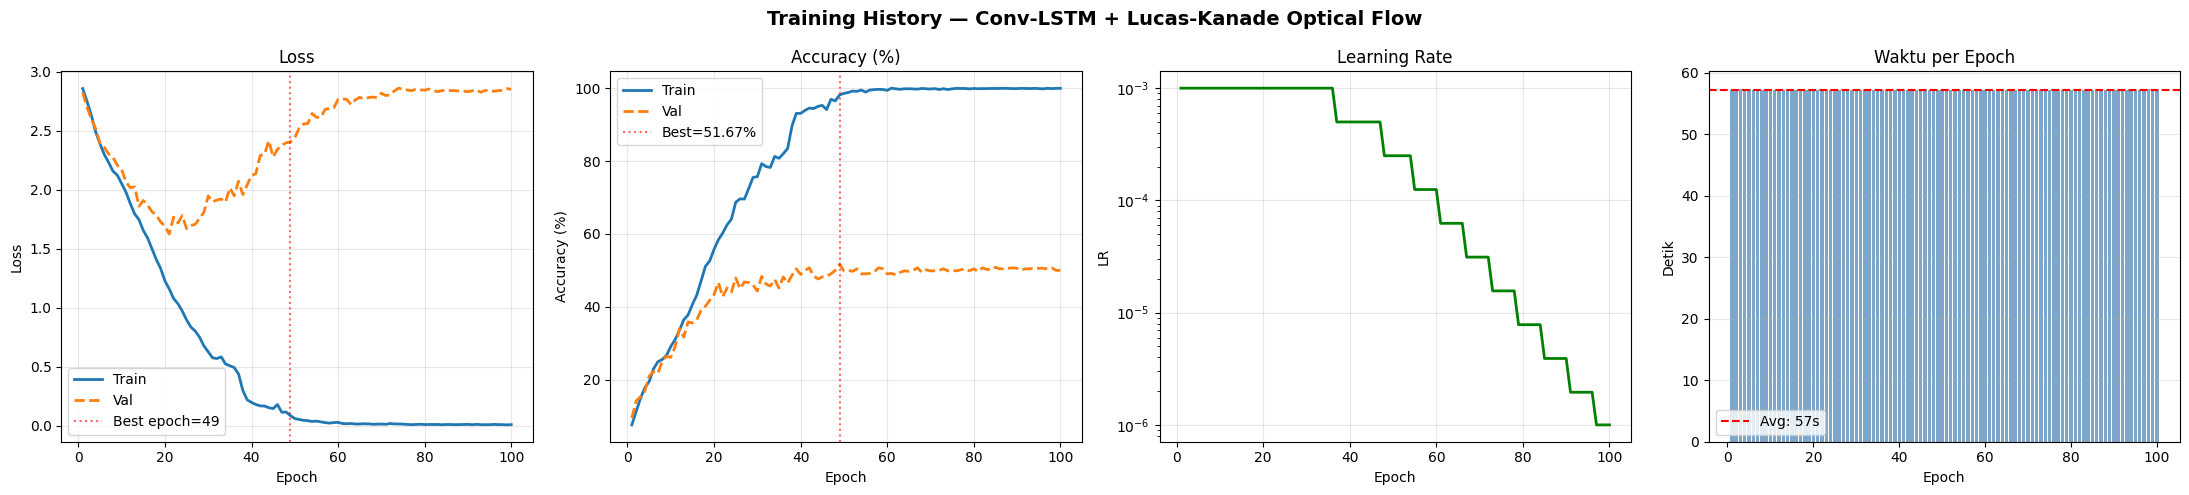

Saved: training_curves.png


In [33]:
# ── Cell 13: Training curves ────────────────────────────────────────────────
ep_ran   = len(history['train_loss'])
ep_range = range(1, ep_ran + 1)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Training History — Conv-LSTM + Lucas-Kanade Optical Flow', fontsize=14, fontweight='bold')

# Loss
axes[0].plot(ep_range, history['train_loss'], label='Train', linewidth=2)
axes[0].plot(ep_range, history['val_loss'],   label='Val',   linewidth=2, linestyle='--')
axes[0].axvline(best_epoch, color='red', linestyle=':', alpha=0.6, label=f'Best epoch={best_epoch}')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(ep_range, history['train_acc'], label='Train', linewidth=2)
axes[1].plot(ep_range, history['val_acc'],   label='Val',   linewidth=2, linestyle='--')
axes[1].axvline(best_epoch, color='red', linestyle=':', alpha=0.6, label=f'Best={best_val_acc:.2f}%')
axes[1].set_title('Accuracy (%)'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)

# Learning Rate
axes[2].plot(ep_range, history['lr'], linewidth=2, color='green')
axes[2].set_title('Learning Rate'); axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR')
axes[2].set_yscale('log'); axes[2].grid(alpha=0.3)

# Epoch time
axes[3].bar(ep_range, history['epoch_time'], color='steelblue', alpha=0.7)
axes[3].axhline(np.mean(history['epoch_time']), color='red', linestyle='--',
                label=f'Avg: {np.mean(history["epoch_time"]):.0f}s')
axes[3].set_title('Waktu per Epoch'); axes[3].set_xlabel('Epoch'); axes[3].set_ylabel('Detik')
axes[3].legend(); axes[3].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')

---
## Evaluasi Test Set

In [34]:
# ── Cell 14: Load best model & test ────────────────────────────────────────
ckpt = torch.load(best_model_path, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
print(f'Loaded best model epoch {ckpt["epoch"]} (val acc: {ckpt["val_acc"]:.2f}%)')

test_loss, test_acc, test_per_cls, test_preds, test_labels = evaluate(
    model, test_loader, criterion, device
)

f1_macro   = f1_score(test_labels, test_preds, average='macro')    * 100
f1_weight  = f1_score(test_labels, test_preds, average='weighted') * 100
prec_macro = precision_score(test_labels, test_preds, average='macro',    zero_division=0) * 100
rec_macro  = recall_score(test_labels,   test_preds, average='macro',     zero_division=0) * 100
prec_w     = precision_score(test_labels, test_preds, average='weighted', zero_division=0) * 100
rec_w      = recall_score(test_labels,   test_preds, average='weighted',  zero_division=0) * 100

print('\n' + '=' * 55)
print('  HASIL EVALUASI TEST SET')
print('=' * 55)
print(f'  Test Loss             : {test_loss:.4f}')
print(f'  Test Accuracy         : {test_acc:.2f}%')
print(f'  Precision (macro)     : {prec_macro:.2f}%')
print(f'  Precision (weighted)  : {prec_w:.2f}%')
print(f'  Recall    (macro)     : {rec_macro:.2f}%')
print(f'  Recall    (weighted)  : {rec_w:.2f}%')
print(f'  F1-score  (macro)     : {f1_macro:.2f}%')
print(f'  F1-score  (weighted)  : {f1_weight:.2f}%')
print('=' * 55)

Loaded best model epoch 49 (val acc: 51.67%)


Eval:   0%|          | 0/45 [00:00<?, ?it/s]


  HASIL EVALUASI TEST SET
  Test Loss             : 2.4128
  Test Accuracy         : 50.83%
  Precision (macro)     : 52.09%
  Precision (weighted)  : 52.09%
  Recall    (macro)     : 50.83%
  Recall    (weighted)  : 50.83%
  F1-score  (macro)     : 50.82%
  F1-score  (weighted)  : 50.82%


In [35]:
# ── Cell 15: Classification report ─────────────────────────────────────────
print('Classification Report per Kelas:\n')
print(classification_report(test_labels, test_preds, target_names=CLASSES, digits=3))

Classification Report per Kelas:

              precision    recall  f1-score   support

           1      0.571     0.600     0.585        20
           2      0.800     0.800     0.800        20
           3      0.412     0.350     0.378        20
           8      0.609     0.700     0.651        20
           9      0.417     0.500     0.455        20
          10      0.469     0.750     0.577        20
           a      0.625     0.500     0.556        20
           b      0.857     0.600     0.706        20
           c      0.318     0.350     0.333        20
           d      0.190     0.200     0.195        20
           e      0.368     0.350     0.359        20
           f      0.542     0.650     0.591        20
        buku      0.571     0.400     0.471        20
         dia      0.722     0.650     0.684        20
        saya      0.294     0.250     0.270        20
    keliling      0.619     0.650     0.634        20
    kelompok      0.643     0.450     0.529    

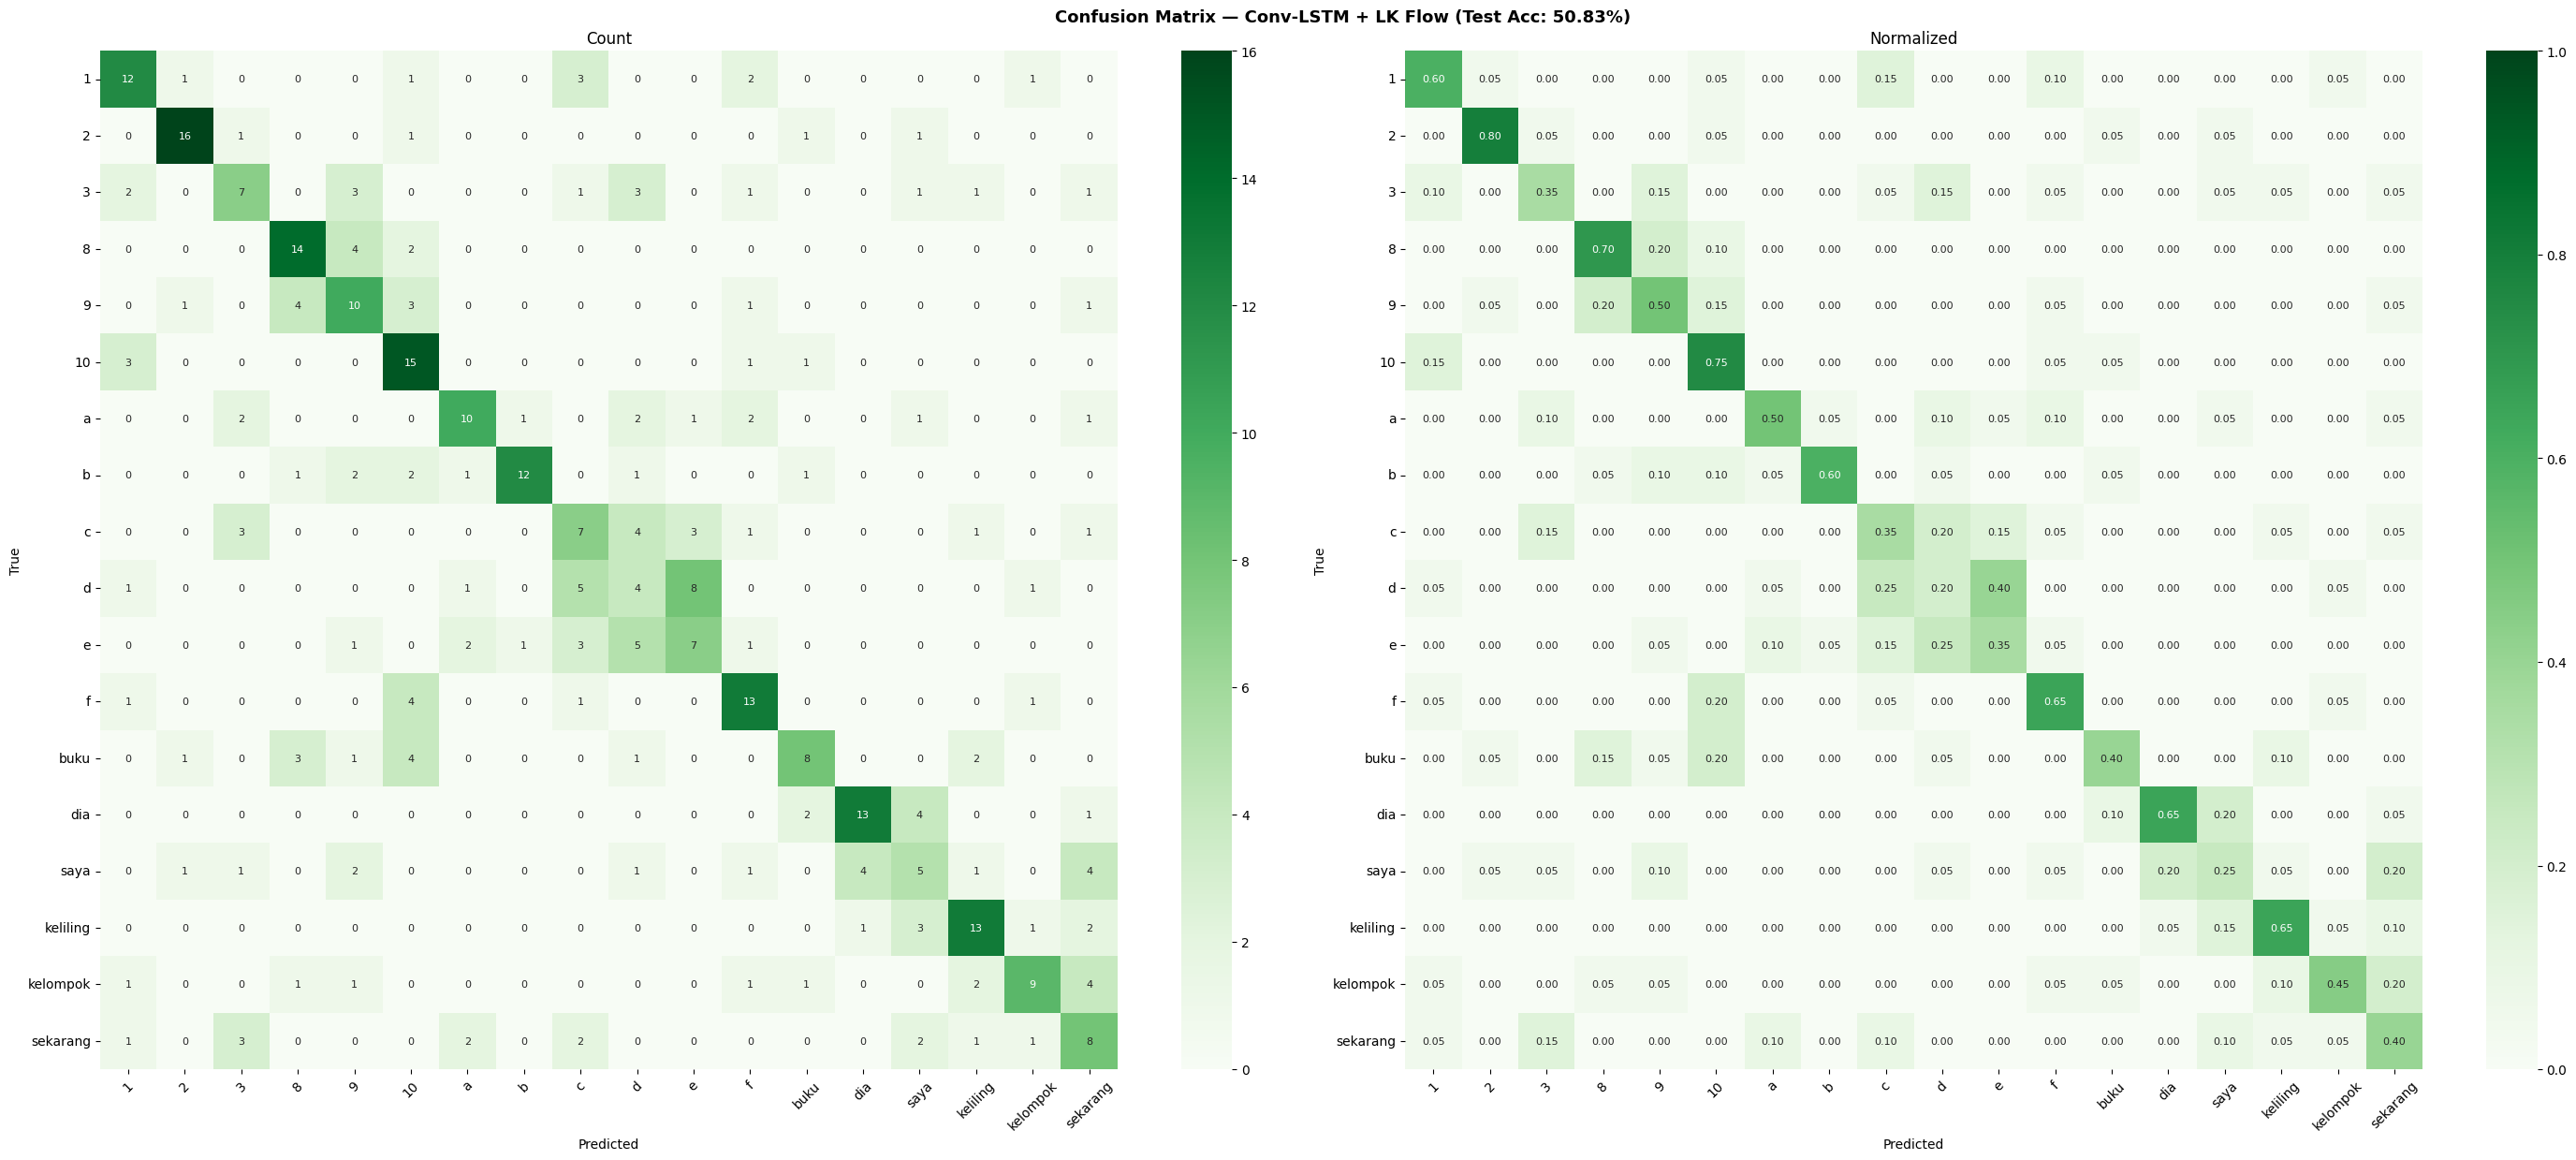

Saved: confusion_matrix.png


In [36]:
# ── Cell 16: Confusion matrix ───────────────────────────────────────────────
cm      = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig_w = max(14, NUM_CLASSES * 0.8)
fig_h = max(10, NUM_CLASSES * 0.7)
fig, axes = plt.subplots(1, 2, figsize=(fig_w * 2, fig_h))
fig.suptitle(f'Confusion Matrix — Conv-LSTM + LK Flow (Test Acc: {test_acc:.2f}%)',
             fontsize=13, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=CLASSES, yticklabels=CLASSES, annot_kws={'size': 8})
axes[0].set_title('Count'); axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens', ax=axes[1],
            xticklabels=CLASSES, yticklabels=CLASSES, annot_kws={'size': 8},
            vmin=0, vmax=1)
axes[1].set_title('Normalized'); axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix.png')

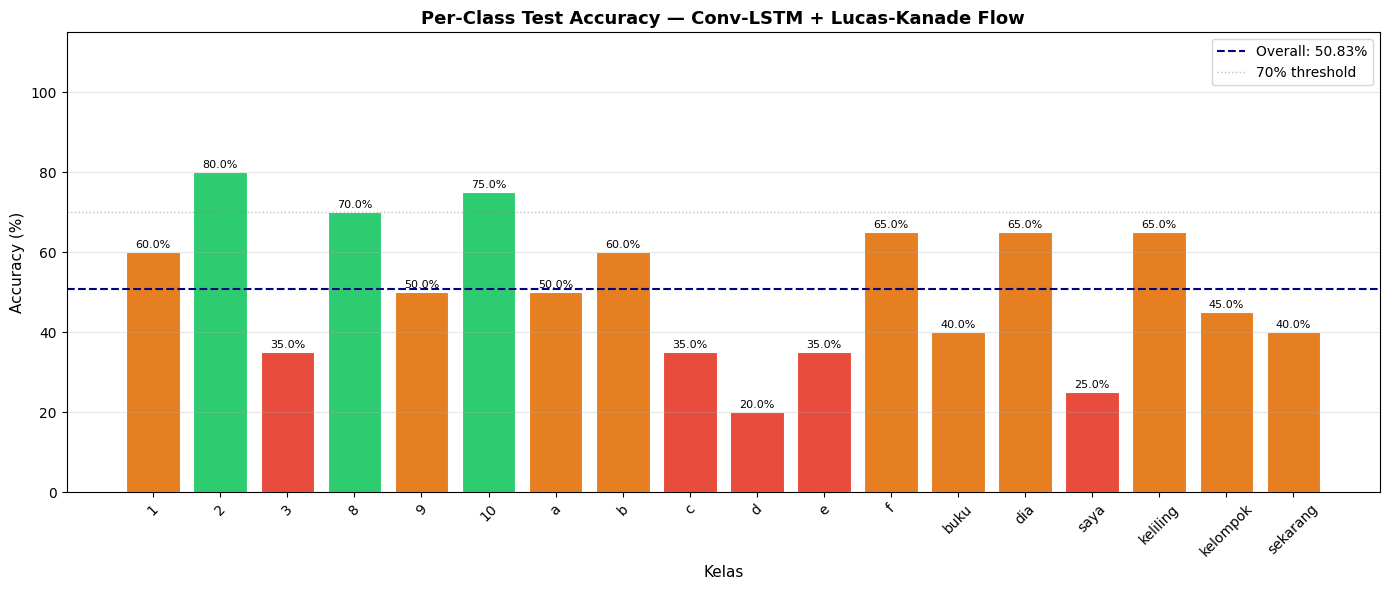

Saved: per_class_accuracy.png


In [37]:
# ── Cell 17: Per-class accuracy bar chart ───────────────────────────────────
class_accs  = [test_per_cls[i] for i in range(NUM_CLASSES)]
colors_bar  = ['#2ecc71' if a >= 70 else '#e67e22' if a >= 40 else '#e74c3c' for a in class_accs]

fig, ax = plt.subplots(figsize=(max(14, NUM_CLASSES * 0.7), 6))
bars = ax.bar(CLASSES, class_accs, color=colors_bar, edgecolor='white', linewidth=0.8)
for bar, acc in zip(bars, class_accs):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=8)
ax.axhline(test_acc, color='navy', linestyle='--', linewidth=1.5, label=f'Overall: {test_acc:.2f}%')
ax.axhline(70, color='gray', linestyle=':', linewidth=1, alpha=0.5, label='70% threshold')
ax.set_xlabel('Kelas', fontsize=11); ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Per-Class Test Accuracy — Conv-LSTM + Lucas-Kanade Flow', fontsize=13, fontweight='bold')
ax.set_ylim([0, 115]); ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: per_class_accuracy.png')

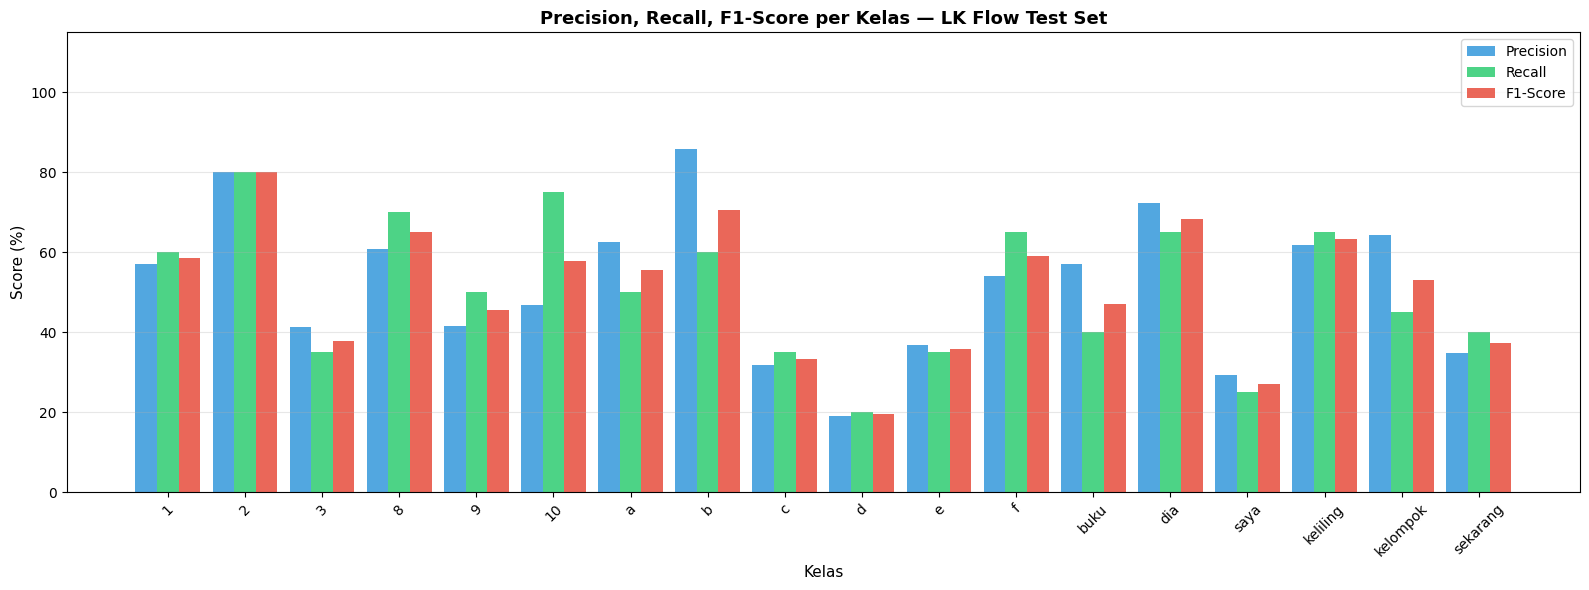

Saved: precision_recall_f1.png


In [38]:
# ── Cell 18: Precision, Recall, F1 per kelas (bar grouped) ──────────────────
report_dict = classification_report(
    test_labels, test_preds, target_names=CLASSES, output_dict=True, zero_division=0
)

prec_per = [report_dict[c]['precision'] * 100 for c in CLASSES]
rec_per  = [report_dict[c]['recall']    * 100 for c in CLASSES]
f1_per   = [report_dict[c]['f1-score']  * 100 for c in CLASSES]

x_pos = np.arange(NUM_CLASSES)
width = 0.28

fig, ax = plt.subplots(figsize=(max(16, NUM_CLASSES * 0.8), 6))
ax.bar(x_pos - width, prec_per, width, label='Precision', color='#3498db', alpha=0.85)
ax.bar(x_pos,         rec_per,  width, label='Recall',    color='#2ecc71', alpha=0.85)
ax.bar(x_pos + width, f1_per,   width, label='F1-Score',  color='#e74c3c', alpha=0.85)
ax.set_xticks(x_pos); ax.set_xticklabels(CLASSES, rotation=45)
ax.set_xlabel('Kelas', fontsize=11); ax.set_ylabel('Score (%)', fontsize=11)
ax.set_title('Precision, Recall, F1-Score per Kelas — LK Flow Test Set', fontsize=13, fontweight='bold')
ax.set_ylim([0, 115]); ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'precision_recall_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: precision_recall_f1.png')

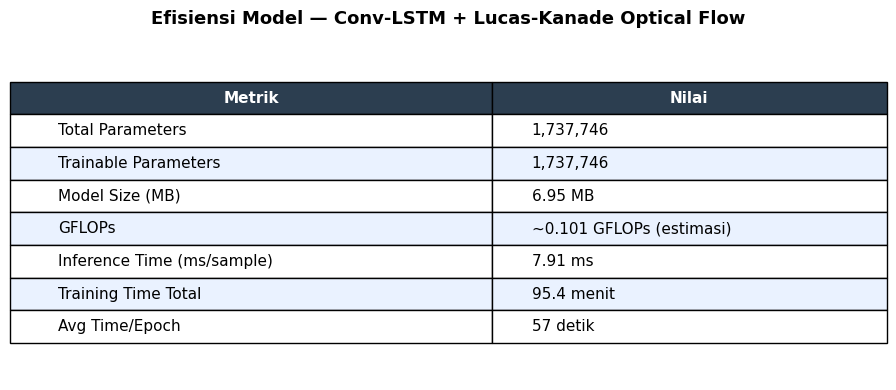

Saved: model_efficiency.png


In [39]:
# ── Cell 19: Ringkasan efisiensi model (tabel visual) ───────────────────────
efficiency_data = {
    'Metrik' : ['Total Parameters', 'Trainable Parameters', 'Model Size (MB)',
                 'GFLOPs', 'Inference Time (ms/sample)',
                 'Training Time Total', 'Avg Time/Epoch'],
    'Nilai'  : [
        f'{total_params:,}',
        f'{trainable_params:,}',
        f'{model_size_mb:.2f} MB',
        gflops_str,
        f'{infer_ms:.2f} ms',
        f'{total_time/60:.1f} menit',
        f'{np.mean(history["epoch_time"]):.0f} detik'
    ]
}

fig, ax = plt.subplots(figsize=(9, 4))
ax.axis('off')
df_eff = pd.DataFrame(efficiency_data)
tbl = ax.table(cellText=df_eff.values, colLabels=df_eff.columns,
               cellLoc='left', loc='center', colWidths=[0.55, 0.45])
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.2, 1.8)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2C3E50')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#EAF2FF')
ax.set_title('Efisiensi Model — Conv-LSTM + Lucas-Kanade Optical Flow',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_efficiency.png')

---
## Simpan Semua Hasil

In [40]:
# ── Cell 20: Save summary JSON + CSV ───────────────────────────────────────
summary = {
    'model'    : 'Conv2D + ConvLSTM (Lucas-Kanade Optical Flow)',
    'dataset'  : 'SIBI Dependent Gabungan',
    'model_info': {
        'total_params'    : total_params,
        'trainable_params': trainable_params,
        'model_size_mb'   : round(model_size_mb, 2),
        'gflops'          : gflops_str,
        'inference_ms'    : round(infer_ms, 2),
        'input_shape'     : f'[B, 3, {SEQ_LEN}, 96, 96]',
        'input_channels'  : 'u, v, magnitude'
    },
    'training' : {
        'epochs_trained'      : ep_ran,
        'best_epoch'          : best_epoch,
        'batch_size'          : BATCH_SIZE,
        'learning_rate'       : LR,
        'weight_decay'        : WEIGHT_DECAY,
        'optimizer'           : 'Adam',
        'scheduler'           : 'ReduceLROnPlateau (max, factor=0.5, patience=5)',
        'augmentation'        : 'horizontal flip + negate u channel',
        'best_val_acc'        : round(best_val_acc, 4),
        'total_time_minutes'  : round(total_time / 60, 2),
        'avg_epoch_time_sec'  : round(np.mean(history['epoch_time']), 1)
    },
    'test_results': {
        'test_loss'           : round(test_loss, 4),
        'accuracy'            : round(test_acc, 4),
        'precision_macro'     : round(prec_macro, 4),
        'precision_weighted'  : round(prec_w, 4),
        'recall_macro'        : round(rec_macro, 4),
        'recall_weighted'     : round(rec_w, 4),
        'f1_macro'            : round(f1_macro, 4),
        'f1_weighted'         : round(f1_weight, 4),
        'per_class_acc'       : {CLASSES[i]: round(acc, 2) for i, acc in enumerate(class_accs)}
    }
}

with open(RESULTS_DIR / 'lk_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

# Training history CSV
pd.DataFrame({
    'epoch'      : range(1, ep_ran + 1),
    'train_loss' : history['train_loss'],
    'train_acc'  : history['train_acc'],
    'val_loss'   : history['val_loss'],
    'val_acc'    : history['val_acc'],
    'lr'         : history['lr'],
    'epoch_time' : history['epoch_time']
}).to_csv(RESULTS_DIR / 'training_history.csv', index=False)

# Classification report CSV
report_rows = []
for cls in CLASSES:
    r = report_dict[cls]
    report_rows.append({'class': cls, 'precision': round(r['precision']*100, 2),
                        'recall': round(r['recall']*100, 2), 'f1': round(r['f1-score']*100, 2),
                        'support': int(r['support'])})
pd.DataFrame(report_rows).to_csv(RESULTS_DIR / 'classification_report.csv', index=False)

print('Files saved:')
all_files = [
    ('models',   'lk_gabungan_best.pth'),
    ('results',  'lk_summary.json'),
    ('results',  'training_history.csv'),
    ('results',  'classification_report.csv'),
    ('results',  'model_architecture.png'),
    ('results',  'sample_flow_frames.png'),
    ('results',  'training_curves.png'),
    ('results',  'confusion_matrix.png'),
    ('results',  'per_class_accuracy.png'),
    ('results',  'precision_recall_f1.png'),
    ('results',  'model_efficiency.png'),
]
for kind, fname in all_files:
    path = (MODELS_DIR if kind == 'models' else RESULTS_DIR) / fname
    print(f'  [{"✓" if path.exists() else "✗"}] {fname}')

print(f'\nLK Flow Training selesai!')
print(f'Test Accuracy  : {test_acc:.2f}%')
print(f'F1 (weighted)  : {f1_weight:.2f}%')
print(f'Best epoch     : {best_epoch}/{ep_ran}')

Files saved:
  [✓] lk_gabungan_best.pth
  [✓] lk_summary.json
  [✓] training_history.csv
  [✓] classification_report.csv
  [✓] model_architecture.png
  [✓] sample_flow_frames.png
  [✓] training_curves.png
  [✓] confusion_matrix.png
  [✓] per_class_accuracy.png
  [✓] precision_recall_f1.png
  [✓] model_efficiency.png

LK Flow Training selesai!
Test Accuracy  : 50.83%
F1 (weighted)  : 50.82%
Best epoch     : 49/100
